# Предсказание стоимости страхового взноса

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
pd.set_option('display.float_format', '{:.6}'.format)

In [70]:
df = pd.read_csv('data/insurance.csv')
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.4
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.4
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.1
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.4
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.9


## EDA

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [72]:
df.isnull().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [73]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.4
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.4
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.1
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.4
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.9


In [74]:
sns.set(style='whitegrid', palette='Set2', font_scale = 1.1)

In [75]:
#проверка дупликатов
df.duplicated().sum()

np.int64(0)

In [76]:
#првоерка пропусков
df.isna().sum().sum()

np.int64(8)

In [77]:
#удаление пропусков
df.dropna(inplace = True)

In [78]:
df.isna().sum().sum()

np.int64(0)

In [80]:
df.describe(include='all')

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.0,1332.0,1332,1332.0,1332.0,1332,1332.0,1332,1332,1332.0
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.474,38.0863,NaN,30.6583,94.1892,NaN,1.09985,NaN,NaN,13325.2
std,384.704,11.1128,NaN,6.11897,11.4452,NaN,1.20596,NaN,NaN,12109.6
min,1.0,18.0,NaN,16.0,80.0,NaN,0.0,NaN,NaN,1121.87
25%,341.75,29.0,NaN,26.2,86.0,NaN,0.0,NaN,NaN,4760.16
50%,674.5,38.0,NaN,30.35,92.0,NaN,1.0,NaN,NaN,9412.97
75%,1007.25,47.0,NaN,34.725,99.0,NaN,2.0,NaN,NaN,16781.3


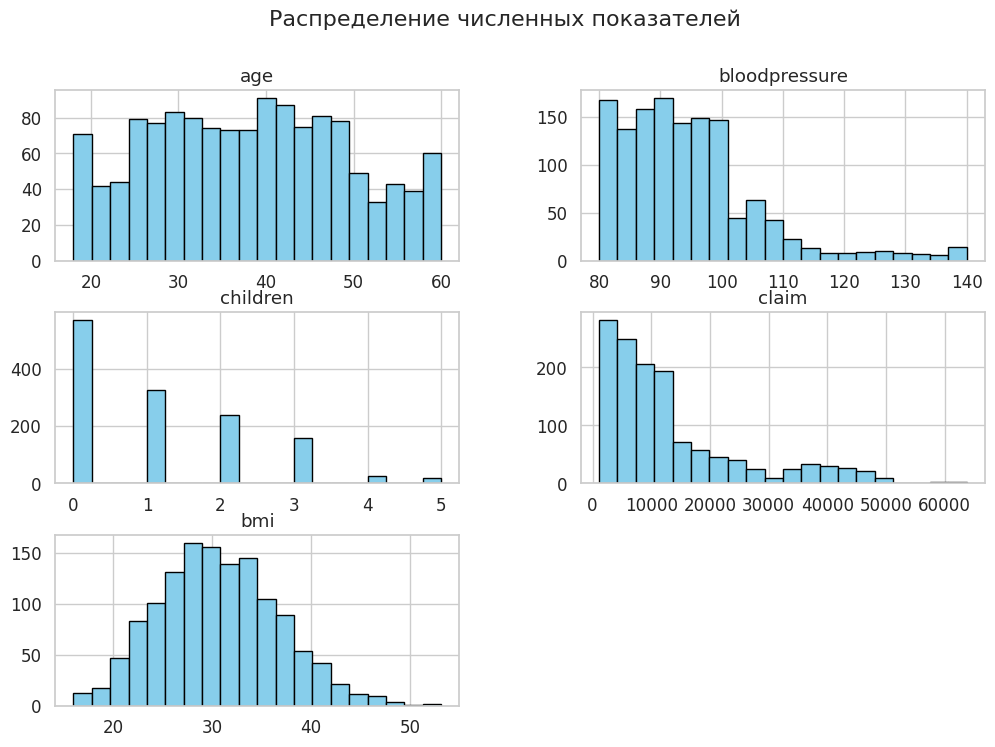

In [83]:
numeric_cols = ['age', 'bloodpressure', 'children', 'claim', 'bmi']
df[numeric_cols].hist(bins = 20, figsize=(12, 8), color = 'skyblue',
                      edgecolor = 'black')

plt.suptitle('Распределение численных показателей', fontsize = 16)

plt.show()

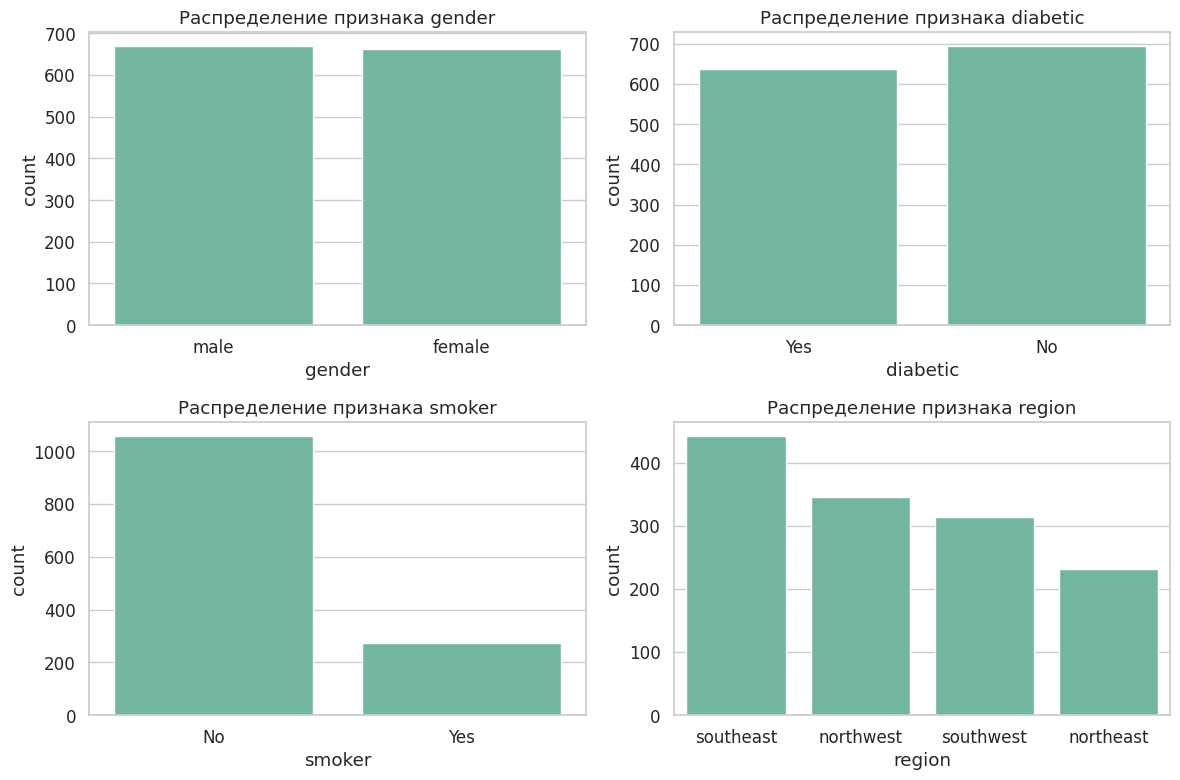

In [84]:
cat_cols = ['gender', 'diabetic', 'smoker', 'region']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data = df, x = col)
    plt.title(f'Распределение признака {col}')

plt.tight_layout()
plt.show()

In [ ]:
#распределение курильщиков в зависимости от пола
df.groupby(['gender', 'smoker'])['claim'].mean().round(2)

gender  smoker
female  No        8762.3
        Yes      30679.0
male    No       8169.25
        Yes      33042.0
Name: claim, dtype: float64

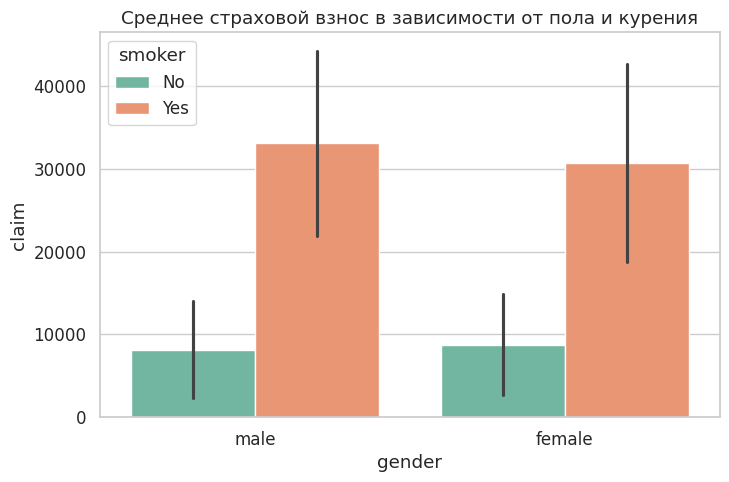

In [89]:
plt.figure(figsize=(8, 5))
sns.barplot(data = df, x='gender', y='claim', 
            hue='smoker', estimator='mean', errorbar='sd')
plt.title('Среднее страховой взнос в зависимости от пола и курения')
plt.show()